# Tuned ElasticNet Regression Model
## T4 Immunological Data
### Targets: pain_reduction_pct 


In [1]:
import sys, os
sys.path.insert(0, '../../src')
import joblib
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skrub import TableReport
import preprocess
import explore
import model
import model_elasticnet
from sklearn.preprocessing import PowerTransformer
os.environ['PYTHONWARNINGS'] = 'ignore'
MODEL_DIR = os.path.abspath('../../models/pain-reduction')


In [2]:
# Running through preprocessing steps
df_im, df_cl = explore.load_data()

# Clean datasets
_im_id_cols = ['Patient', 'Timepoint', 'Date']
df_im_vis   = preprocess.clean_im(df_im, False)
df_cl_vis   = preprocess.clean_cl(df_cl, False)

# Immunological: drop >25% NaN columns, remove confirmed outliers
df_im_mod    = preprocess.remove_nan_cols(df_im_vis, verbose=False)
df_im_mod    = preprocess.remove_outlier_observations(df_im_mod, verbose=False)
df_im_mod    = preprocess.remove_for_modeling(df_im_mod, verbose=False)
# Clinical: drop >25% NaN columns
df_cl_mod    = preprocess.remove_nan_cols(df_cl_vis, verbose=False)
df_cl_mod    = preprocess.remove_outlier_observations(df_cl_mod, verbose=False)
df_cl_mod    = preprocess.remove_for_modeling(df_cl_mod, verbose=False)

In [3]:
# Creating Target for pain scale
print('\nConstructing regression targets from clinical data')
pain_targets       = model.construct_datasets_targets(df_cl_mod, 'pain_scale',      [1, 4])

# Constructing dataset for modeling with targets and im + cl data
print('\nConstructing datasets for modeling:')
df_pain = model.create_model_datasets(df_im_mod, df_cl_mod, pain_targets, timepoints=[4])

pt = PowerTransformer(method='yeo-johnson', standardize=True)



Constructing regression targets from clinical data

  Target distributions:
    pain_reduction                              mean=3.164  std=2.497  [-2.800, 8.500]
    pain_reduction_pct                          mean=45.016  std=35.256  [-70.000, 94.444]

Constructing datasets for modeling:

Modeling dataset ready: T4 features + clinical features
Shape: (77, 95),  Patients: 77


## Dataset Overview

In [2]:
# Censored from Gitlab
#TableReport(df_pain, max_plot_columns=100)

# Correlations between Features and Target (T4)

In [4]:
importlib.reload(explore)
ex_cols = ['Patient', 'Timepoint','pain_reduction']

explore.target_correlation(
    df_pain,
    target_col='pain_reduction_pct',
    ex_cols=ex_cols,
    name='Modeling Dataset and Target Correlations', plot=False)


Target Correlation (Modeling Dataset and Target Correlations)    Target: pain_reduction_pct

Positive Correlations with pain_reduction_pct (> 0.05):
  Feature                                       Method      Correlation
  -----------------------------------------------------------------
  TC CM_PD1+_t4                                 Spearman         0.2166
  mDC-1_t4                                      Spearman         0.1903
  Tc/Treg_t4                                    Spearman         0.1591
  TH_CD69+_t4                                   Spearman         0.1317
  previous_therapy_5                            Spearman         0.1312
  NK_CD69+_t4                                   Spearman         0.1052
  mDC-2_t4                                      Spearman         0.0948
  NKT_56+_t4                                    Spearman         0.0906
  TH EM_PD1+_t4                                 Spearman         0.0872
  T_CD69+_t4                                    Spearman      

,Feature,Method,Correlation,Abs_correlation,p_value
0,target_volume,Phik,0.5901,0.5901,NaN
1,diagnosis,Phik,0.5156,0.5156,NaN
2,target_volume_side,Phik,0.2921,0.2921,NaN
3,cumulative_dose,Spearman,-0.2811,0.2811,0.0153
4,NKT_16+_t4,Spearman,-0.2702,0.2702,0.0175
...,...,...,...,...,...
87,TH_CD25hi_t4,Spearman,0.0044,0.0044,0.9700
88,Neu_HLADR+_t4,Spearman,0.0025,0.0025,0.9829
89,age_at_start,Spearman,0.0020,0.0020,0.9859
90,gender,Phik,0.0000,0.0000,NaN


## Elasticnet + MRMR Feature selection 
### Nested CV and Optuna hyperparameter tuning

### Target: pain_reduction_pct

In [5]:
importlib.reload(model_elasticnet)
_, en_feature_freq4, en_sel_per_fold4 = model_elasticnet.elasticnet_mrmr(
        df_pain,
        target_col='pain_reduction_pct',
        random_state=42,
        target_transformer=pt)

# Save feature frequency list and selections per outer fold:
joblib.dump(en_feature_freq4,         os.path.join(MODEL_DIR, 'en_feature_freq4.pkl'))
joblib.dump(en_sel_per_fold4,         os.path.join(MODEL_DIR, 'en_sel_per_fold4.pkl'))



 Nested CV - ElasticNet + MRMR + Optuna — pain_reduction_pct
  n=77, p=92
  Outer 4x5=20 | Inner 4x5=20 | Optuna Trials Model=50 | Optuna Trials MRMR=20

─────────────────────────────────────────────────────────────────
  Outer fold 1/20
─────────────────────────────────────────────────────────────────
    MRMR Trial  1/20: RMSE=1.2175  {'K': 15, 'n_estimators': 100, 'max_depth': 8, 'min_samples_leaf': 14}
    MRMR Trial  2/20: RMSE=1.2175  {'K': 20, 'n_estimators': 100, 'max_depth': 4, 'min_samples_leaf': 13}
    MRMR Trial  3/20: RMSE=1.2175  {'K': 20, 'n_estimators': 400, 'max_depth': 7, 'min_samples_leaf': 8}
    MRMR Trial  4/20: RMSE=1.2175  {'K': 15, 'n_estimators': 400, 'max_depth': 8, 'min_samples_leaf': 17}
    MRMR Trial  5/20: RMSE=1.2175  {'K': 20, 'n_estimators': 300, 'max_depth': 8, 'min_samples_leaf': 9}
    MRMR Trial  6/20: RMSE=1.2175  {'K': 10, 'n_estimators': 300, 'max_depth': 8, 'min_samples_leaf': 19}
    MRMR Trial  7/20: RMSE=1.2175  {'K': 15, 'n_estimators': 

['p:\\UK_Erlangen\\Student_folders\\Muna Ahmed Farah - IMMO-LDRT01\\master-thesis\\models\\pain-reduction\\en_sel_per_fold4.pkl']

## Plot of Feature Frequency List 
Top 25 Features Selections Shown.

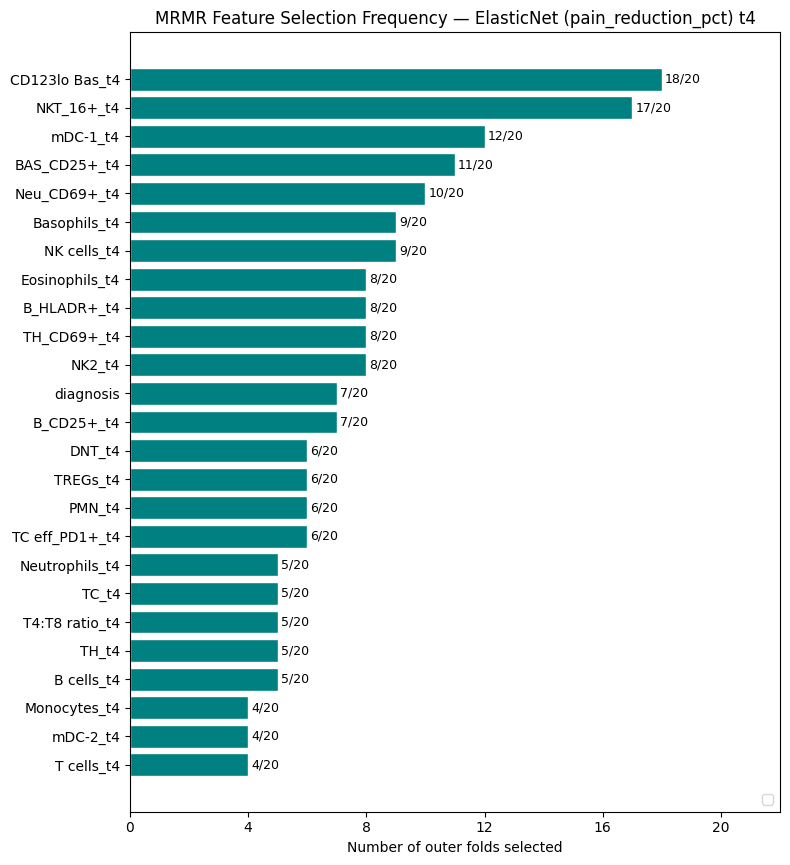

In [6]:
feature_list = joblib.load(os.path.join(MODEL_DIR, 'en_feature_freq4.pkl'))
model.plot_feature_frequency(feature_list, name='ElasticNet (pain_reduction_pct) t4', top=25)

## Jaccard Score of MRMR Selected Features
### Pairwise (20 Outer Folds x 20 Outer Folds)  Comparisons


  Jaccard Scores — ElasticNet (MRMR Feat. Sel.) t4
  Folds: 20   Pairs evaluated: 190
  Mean Jaccard : 0.205 ± 0.137
  Min  Jaccard : 0.000
  Max  Jaccard : 0.875


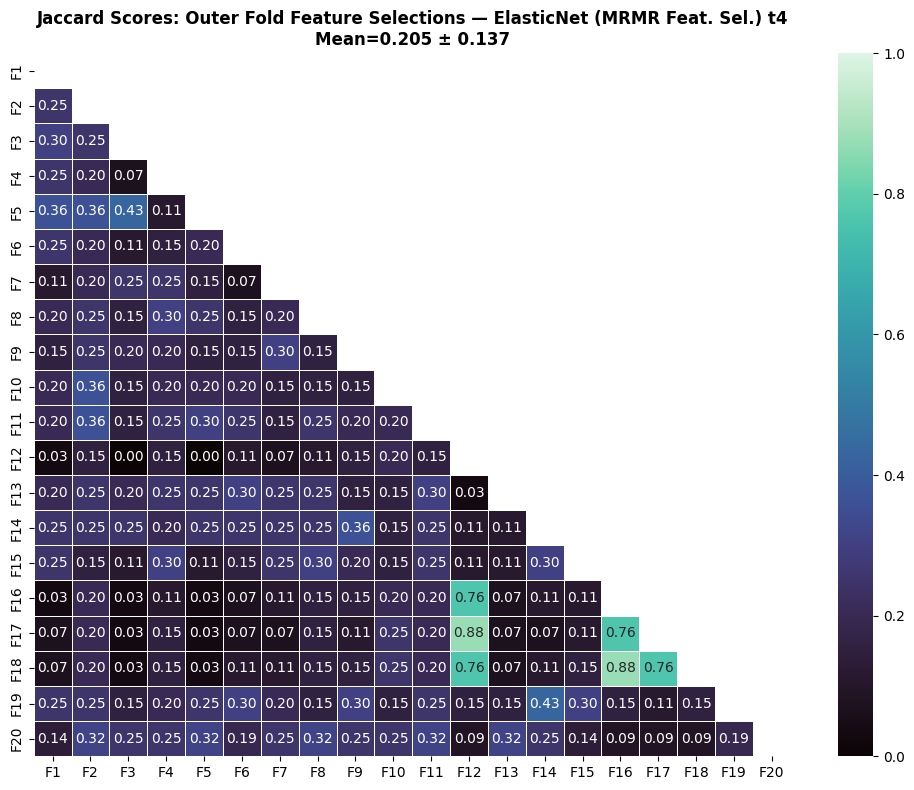

In [7]:
selected_per_fold = joblib.load(os.path.join(MODEL_DIR, 'en_sel_per_fold4.pkl'))
jac_matrix = model.jaccard_scores(selected_per_fold, name='ElasticNet (MRMR Feat. Sel.) t4')

#### Using MRMR Selected Features Moving Forward

 # ElasticNet on Different Subsets of Selected Features
 ## Target: pain_reduction_pct

In [8]:
importlib.reload(model_elasticnet)
feature_list = joblib.load(os.path.join(MODEL_DIR, 'en_feature_freq4.pkl'))

en_sweep_df4 = model_elasticnet.elasticnet_threshold_analysis(
     df_pain, 
     feature_list, 
     target_col='pain_reduction_pct',
     random_state=42, 
     target_transformer=pt)
joblib.dump(en_sweep_df4,      os.path.join(MODEL_DIR, 'en_sweep_df4.pkl'))



  Threshold  all ( ):  94 features
  ['CD123lo Bas_t4', 'NKT_16+_t4', 'mDC-1_t4', 'BAS_CD25+_t4', 'Neu_CD69+_t4', 'Basophils_t4', 'NK cells_t4', 'Eosinophils_t4']...
  Outer Fold  1/20:  Best Trial 13/50  RMSE=1.0069  {'alpha': 8.19260227903101, 'l1_ratio': 0.3438675441130149}
  Outer Fold  2/20:  Best Trial 49/50  RMSE=0.9860  {'alpha': 0.47957491191887064, 'l1_ratio': 0.11221870639925816}
  Outer Fold  3/20:  Best Trial 43/50  RMSE=0.9953  {'alpha': 1.2728712989607371, 'l1_ratio': 0.05889607284924806}
  Outer Fold  4/20:  Best Trial 19/50  RMSE=1.0002  {'alpha': 0.485610459483116, 'l1_ratio': 0.5916836359300597}
  Outer Fold  5/20:  Best Trial  2/50  RMSE=1.0141  {'alpha': 0.4570563099801455, 'l1_ratio': 0.5986584841970366}
  Outer Fold  6/20:  Best Trial 30/50  RMSE=0.9949  {'alpha': 0.8107600918610282, 'l1_ratio': 0.2651151650206655}
  Outer Fold  7/20:  Best Trial 11/50  RMSE=0.9009  {'alpha': 0.1466347391866951, 'l1_ratio': 0.7171409693086566}
  Outer Fold  8/20:  Best Trial 40/

['p:\\UK_Erlangen\\Student_folders\\Muna Ahmed Farah - IMMO-LDRT01\\master-thesis\\models\\pain-reduction\\en_sweep_df4.pkl']

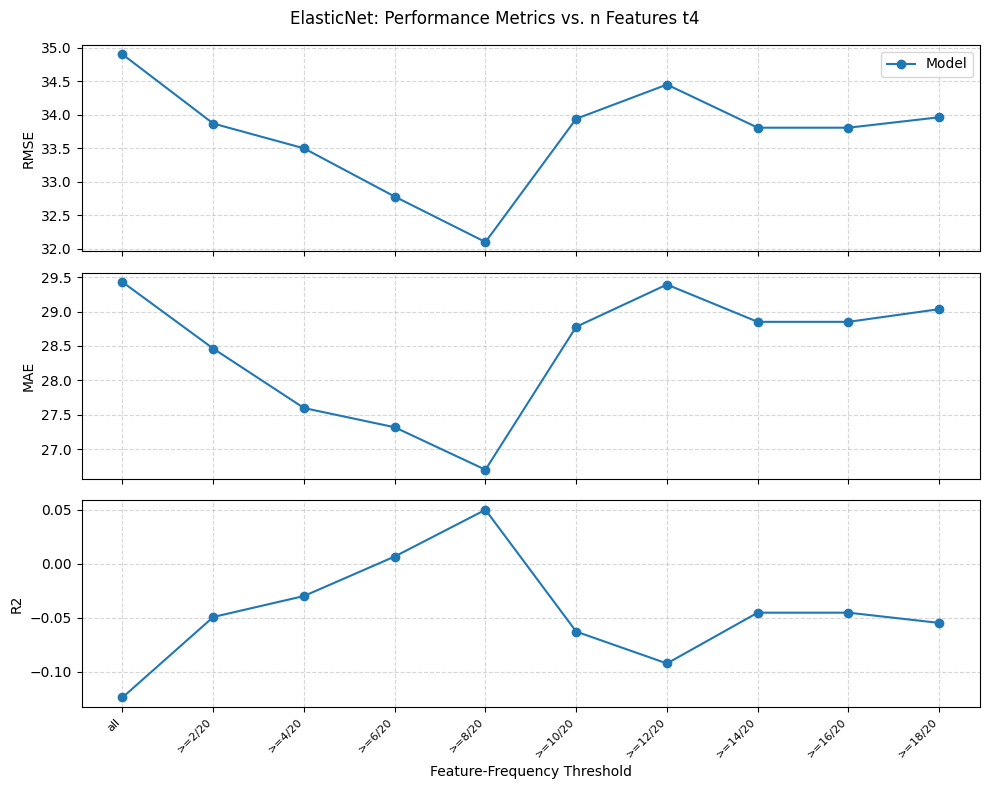

In [9]:
# Plot performances on different feature-tresholds
importlib.reload(model)
model.plot_sweep(en_sweep_df4, title='ElasticNet: Performance Metrics vs. n Features t4')

# ____________________________________________________________________________
## Final ElasticNet Model 
### Using Features Selected in More Than 8/20 Outer Folds 

In [4]:
en_feature_freq = joblib.load(os.path.join(MODEL_DIR, 'en_feature_freq4.pkl'))
# selecting features in more than 8/20 outer folds:
sel_features = en_feature_freq[en_feature_freq >= 8].index.tolist()

en_results_df4, en_model4, en_X_final4, en_y_pred4, en_patient_err4, en_err_df4, en_scaler4, en_errors4 = model_elasticnet.run_tuned_elasticnet(
    df_pain, 
    sel_features,
    target_col='pain_reduction_pct', 
    random_state=42,
    target_transformer=pt)

# save results
joblib.dump(en_results_df4,                os.path.join(MODEL_DIR, 'en_results_df4.pkl'))
joblib.dump(en_model4,                os.path.join(MODEL_DIR, 'en_model4.pkl'))
joblib.dump(en_X_final4,              os.path.join(MODEL_DIR, 'en_X_final4.pkl'))
joblib.dump(en_patient_err4,          os.path.join(MODEL_DIR, 'en_patient_err4.pkl'))
joblib.dump(en_err_df4,               os.path.join(MODEL_DIR, 'en_err_df4.pkl'))
joblib.dump(en_scaler4,               os.path.join(MODEL_DIR, 'en_scaler4.pkl'))
joblib.dump(en_errors4,               os.path.join(MODEL_DIR, 'en_errors4.pkl'))


  ElasticNet + Optuna — pain_reduction_pct
  n=77, p=11
  Outer 4x5=20 | Inner 4x5=20 | Optuna trials Model=50

─────────────────────────────────────────────────────────────────
  Outer fold 1/20
─────────────────────────────────────────────────────────────────
    Trial   1/50: RMSE=1.0958  {'alpha': 0.0074593432857265485, 'l1_ratio': 0.9507143064099162}
    Trial   2/50: RMSE=1.0077  {'alpha': 0.4570563099801455, 'l1_ratio': 0.5986584841970366}
    Trial   3/50: RMSE=1.1276  {'alpha': 0.0006026889128682511, 'l1_ratio': 0.15599452033620265}
    Trial   4/50: RMSE=1.1283  {'alpha': 0.00019517224641449495, 'l1_ratio': 0.8661761457749352}
    Trial   5/50: RMSE=0.9950  {'alpha': 0.10129197956845731, 'l1_ratio': 0.7080725777960455}
    Trial   6/50: RMSE=1.1286  {'alpha': 0.00012674255898937226, 'l1_ratio': 0.9699098521619943}
    Trial   7/50: RMSE=1.0070  {'alpha': 1.452824663751602, 'l1_ratio': 0.21233911067827616}
    Trial   8/50: RMSE=1.1269  {'alpha': 0.0008111941985431928, 'l1_ra

['p:\\UK_Erlangen\\Student_folders\\Muna Ahmed Farah - IMMO-LDRT01\\master-thesis\\models\\pain-reduction\\en_errors4.pkl']

## Difficult Patient-Predictions

In [9]:
patient_err = joblib.load(os.path.join(MODEL_DIR, 'en_patient_err4.pkl'))
print(patient_err.to_string())

         mean_mae  mean_true  mean_pred  n_folds
Patient                                         
202         86.53     -33.33      53.19        5
116         73.85     -20.00      53.85        5
239         72.27     -23.08      49.19        5
122         62.41      -5.38      57.03        5
76          54.38      94.44      40.07        5
222         53.07     -25.00      28.07        5
241         50.93       0.00      50.93        5
174         50.67       0.00      50.67        5
221         48.57      87.50      38.93        5
196         45.32      88.24      42.91        5
93          45.02       0.00      45.02        5
183         42.21       0.00      42.21        5
72          41.17      -5.56      35.62        5
185         39.10      87.50      48.40        5
131         38.80      12.50      51.30        5
188         38.69      16.67      55.36        5
189         38.41       0.00      38.41        5
91          38.27      77.61      39.34        5
181         38.03   

In [10]:
difficult_patients = patient_err.head(10).index.tolist()

pain_data = (df_cl_mod[df_cl_mod['Patient'].isin(difficult_patients)]
             [['Patient', 'Timepoint', 'pain_scale']].pivot(index='Patient', columns='Timepoint', values='pain_scale'))
pain_data.columns = [f'pain_t{c}' for c in pain_data.columns]

difficult_df = (pain_data
                .merge(patient_err[['mean_mae']], left_index=True, right_index=True)
                .sort_values('mean_mae', ascending=False))[['pain_t1', 'pain_t2', 'mean_mae']]


print('Difficult Patient-Predictions and Pain Scale Values:')
display(difficult_df)

Difficult Patient-Predictions and Pain Scale Values:


,pain_t1,pain_t2,mean_mae
Patient,,,
202,6.0,4.5,86.53
116,5.0,5.5,73.85
239,6.5,7.0,72.27
122,9.3,9.8,62.41
76,9.0,4.4,54.38
222,4.0,3.5,53.07
241,6.0,NaN,50.93
174,4.0,2.0,50.67
221,8.0,NaN,48.57


## Prediction-Error Heatmap

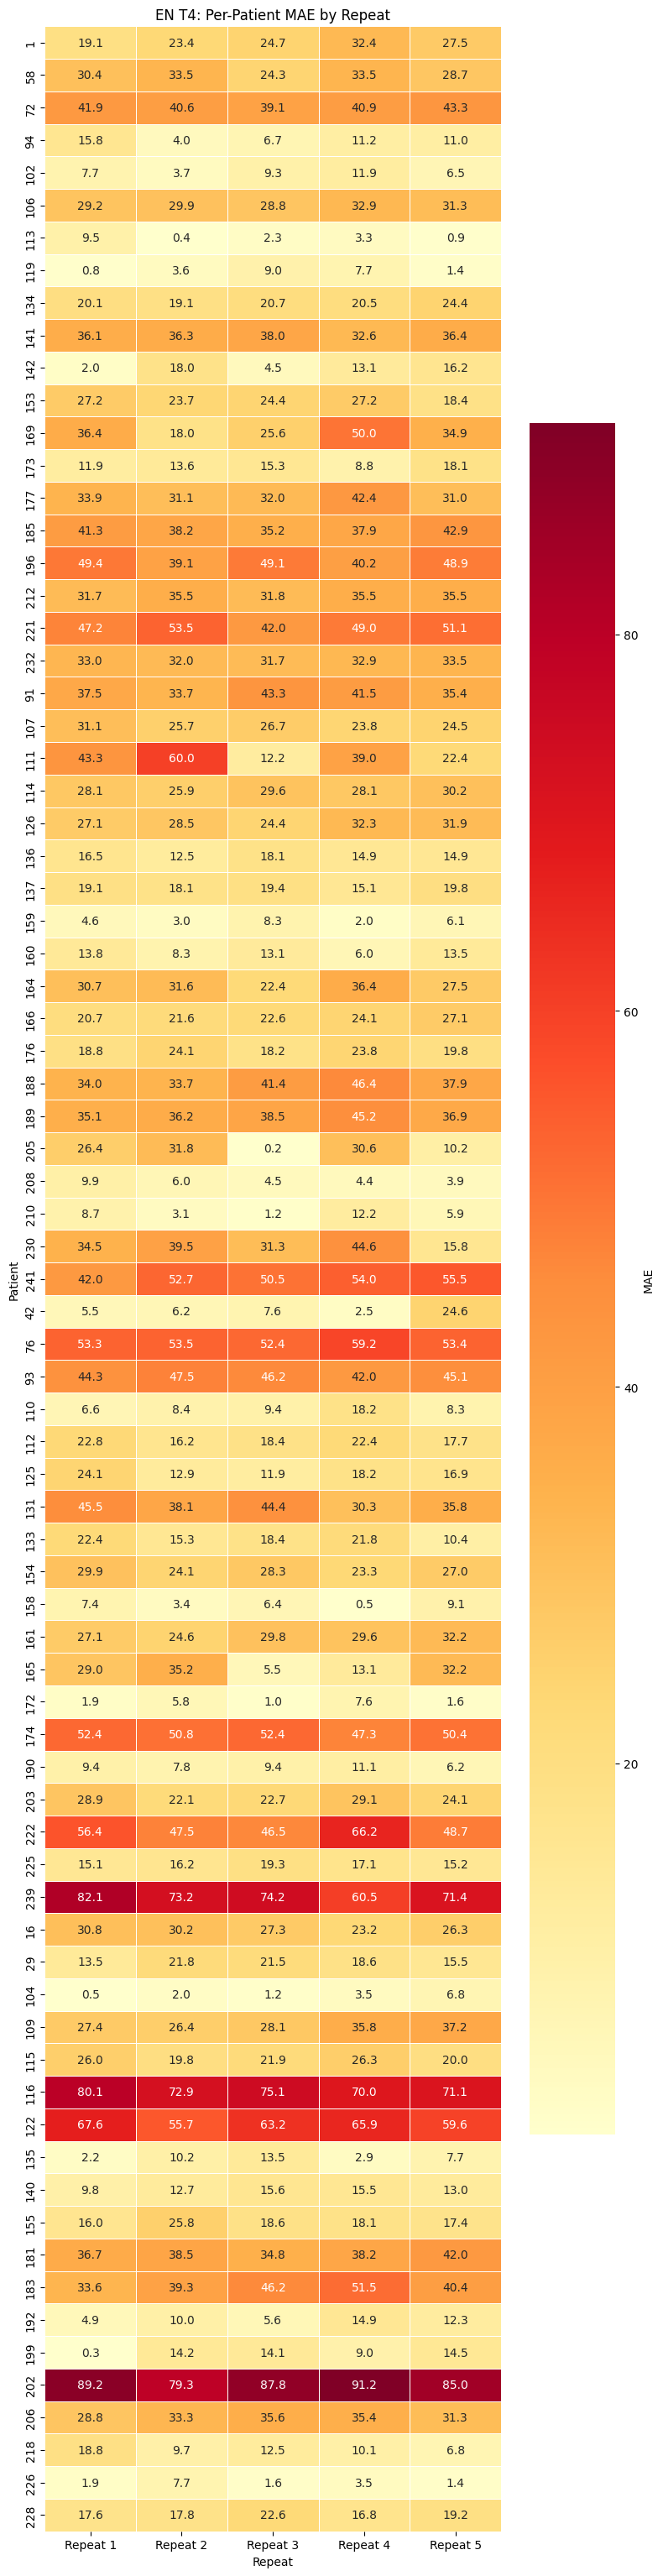

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
# Order by appearance across folds (fold 1 first, then fold 2, etc.)
seen = []

for e in en_errors4:
    if e['Patient'] not in seen:
        seen.append(e['Patient'])

heatmap_data = en_err_df4.loc[seen]

fig, ax = plt.subplots(figsize=(8, max(4, len(heatmap_data) * 0.4)))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'MAE'})
ax.set_title('EN T4: Per-Patient MAE by Repeat')
ax.set_xlabel('Repeat')
ax.set_ylabel('Patient')
plt.tight_layout()
plt.show()



## SHAP-values Plot


=== SHAP Analysis: Elasticnet ===


Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

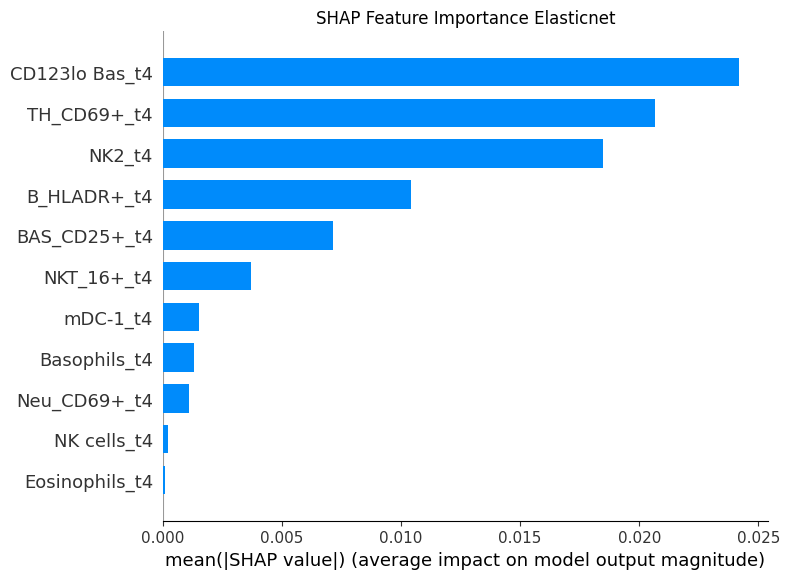

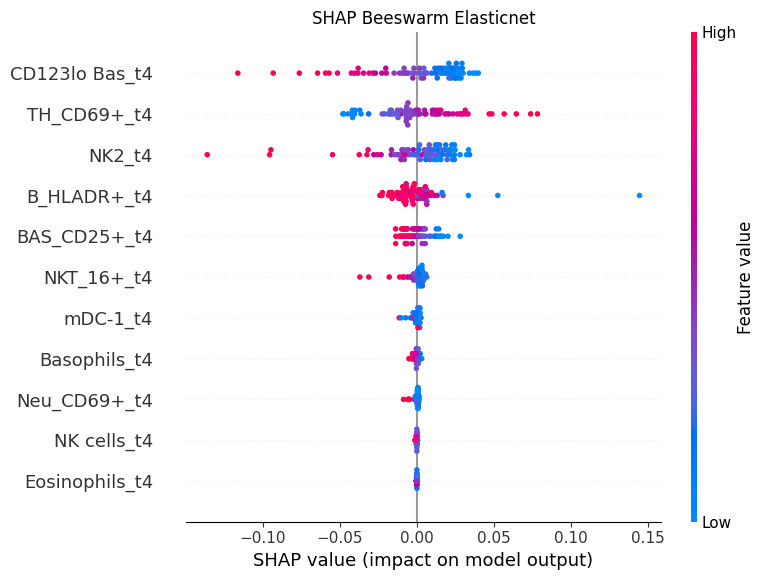

In [14]:
# Plot Shap values
en_model= joblib.load(os.path.join(MODEL_DIR, 'en_model4.pkl'))
en_X_final = joblib.load(os.path.join(MODEL_DIR, 'en_X_final4.pkl'))
en_scaler = joblib.load(os.path.join(MODEL_DIR, 'en_scaler4.pkl'))

en_shap = model.plot_shap_elasticnet(en_model, en_X_final, en_scaler)


## Dummy Model

In [4]:
en_dummy_results = model_elasticnet.run_dummy_enet(
    df_pain,
    target_col='pain_reduction_pct',
    random_state=42,       
    target_transformer=pt)


  Dummy Regressor — pain_reduction_pct
    MAE  : 29.116 ± 3.3223
    MSE  : 1145.650 ± 227.6491
    RMSE : 33.672 ± 3.5274
    R2   : -0.035 ± 0.0402
